## Practical 1 — From Real Biological Data to an ML-Ready Dataset
## Bladder cancer microarray data, data quality, grouping, and batch effects

## Learning goals

By the end of this practical, you should be able to:

- identify observations, features, metadata, targets, and technical variables in a real biological dataset;
- recognize the orientation and dimensionality of an expression matrix;
- apply tidy-data principles to biological measurements and metadata;
- perform systematic data diagnostics even when no obvious data-entry errors are present;
- transform a real expression dataset into an ML-ready representation;
- explain why repeated or highly related observations must remain in the same data split;
- distinguish **real batch structure** from an **artificial pseudo grouping**;
- detect evidence of batch effects and target–batch confounding;
- independently apply the same workflow to the UCI Mice Protein Expression dataset.

**Main idea:** a model sees numerical representations. It does not assume which variation is biological, technical, duplicated, or leaked across the train/test boundary.

# 0. Dataset check


We use the Bioconductor **`bladderbatch`** dataset: an Affymetrix microarray bladder-cancer dataset containing **57 samples, 22,283 probe-set expression measurements, and five processing batches**.

The Bioconductor metadata include:

- `sample` — sample number;
- `outcome` — original biological outcome;
- `batch` — processing batch defined by the date on which arrays were processed;
- `cancer` — a simplified biological outcome.

The expression data were RMA-normalized before inclusion in the package.

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

DATA = Path(".")
RANDOM_STATE = 1090926

In [2]:
expression_raw = pd.read_csv(DATA / "bladder_expression_raw.csv")
metadata = pd.read_csv(DATA / "bladder_metadata.csv")

print("Raw expression:", expression_raw.shape)
print("Metadata:", metadata.shape)

Raw expression: (22283, 58)
Metadata: (57, 5)


In [3]:
metadata

,sample_id,sample,outcome,batch,cancer
0,GSM71019.CEL,1,Normal,3,Normal
1,GSM71020.CEL,2,Normal,2,Normal
2,GSM71021.CEL,3,Normal,2,Normal
3,GSM71022.CEL,4,Normal,3,Normal
4,GSM71023.CEL,5,Normal,3,Normal
5,GSM71024.CEL,6,Normal,3,Normal
6,GSM71025.CEL,7,Normal,2,Normal
7,GSM71026.CEL,8,Normal,2,Normal
8,GSM71028.CEL,9,sTCC+CIS,5,Cancer
9,GSM71029.CEL,10,sTCC-CIS,2,Cancer


In [5]:
expression_raw.head()

,probe_set_id,GSM71019.CEL,GSM71020.CEL,GSM71021.CEL,GSM71022.CEL,GSM71023.CEL,GSM71024.CEL,GSM71025.CEL,GSM71026.CEL,GSM71028.CEL,...,GSM71068.CEL,GSM71069.CEL,GSM71070.CEL,GSM71071.CEL,GSM71072.CEL,GSM71073.CEL,GSM71074.CEL,GSM71075.CEL,GSM71076.CEL,GSM71077.CEL
0,1007_s_at,10.115170,8.628044,8.779235,9.248569,10.256841,10.023133,9.108034,8.735616,9.803271,...,10.582892,10.009028,9.912853,9.096809,9.011927,8.396062,8.903465,9.501538,9.540766,9.039143
1,1053_at,5.345168,5.063598,5.113116,5.179410,5.181383,5.248418,5.252312,5.220931,5.595771,...,5.615926,5.151548,5.237126,5.093278,5.353248,5.214357,5.251383,5.223598,5.191392,5.235880
2,117_at,6.348024,6.663625,6.465892,6.116422,5.980457,5.796155,6.414849,6.846798,5.841478,...,5.913488,5.904794,5.960948,6.394089,6.425034,6.372520,6.095344,5.811968,6.007461,6.314809
3,121_at,8.901739,9.439977,9.540738,9.254368,8.798086,8.002870,9.093704,9.263386,7.789240,...,8.049998,8.407351,8.985741,8.817789,8.866083,8.704385,9.375736,8.580523,8.848099,9.663298
4,1255_g_at,3.967672,4.466027,4.144885,4.189338,4.078509,3.919740,4.402590,4.173666,3.590649,...,3.775194,3.995371,4.322380,4.141255,3.997644,4.219360,4.454771,4.188310,4.284053,4.877523


## 1.2 Prepare the expression matrix for scikit-learn

The raw export preserves the original assay orientation: probe sets are rows and biological samples are columns. Most scikit-learn workflows/tidy data principles expect the opposite orientation: samples are rows and features are columns.

We now transpose the matrix in Python and use the sample identifiers from the column names as `sample_id`. The resulting `expression` table is the ML-ready expression table used below.

In [4]:
expression = expression_raw.set_index("probe_set_id").T.rename_axis("sample_id").reset_index()
expression.columns.name = None

print(expression_raw.shape)
print(expression.shape)


(22283, 58)
(57, 22284)


In [5]:
expression

,sample_id,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,1405_i_at,...,AFFX-r2-Hs28SrRNA-5_at,AFFX-r2-Hs28SrRNA-M_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
0,GSM71019.CEL,10.115170,5.345168,6.348024,8.901739,3.967672,7.775183,5.655863,4.855069,4.942097,...,5.889822,6.255983,11.772870,11.650434,4.295802,3.902905,3.396659,3.319554,3.637277,3.475397
1,GSM71020.CEL,8.628044,5.063598,6.663625,9.439977,4.466027,7.110154,6.068074,4.971663,4.892139,...,6.875853,6.832614,13.301387,13.092792,4.391424,3.725786,4.011382,3.477539,3.909711,3.710860
2,GSM71021.CEL,8.779235,5.113116,6.465892,9.540738,4.144885,7.248430,5.822590,4.955943,4.991248,...,5.400099,6.301081,13.682598,13.497060,4.380636,4.139661,3.799011,3.491621,3.885286,3.524983
3,GSM71022.CEL,9.248569,5.179410,6.116422,9.254368,4.189338,7.017220,5.659677,5.028884,5.163996,...,5.361622,5.519502,12.136462,11.808322,4.453195,3.838170,3.703706,3.392606,3.762326,3.783900
4,GSM71023.CEL,10.256841,5.181383,5.980457,8.798086,4.078509,7.896419,5.480801,4.838721,5.666031,...,6.549468,7.006766,11.918717,11.822269,4.298520,3.889372,3.530179,3.382881,3.777308,3.439520
5,GSM71024.CEL,10.023133,5.248418,5.796155,8.002870,3.919740,7.944676,5.141930,4.688610,5.635379,...,7.146261,7.351801,11.770457,11.609514,4.180763,3.888782,3.378287,3.341418,3.631794,3.438930
6,GSM71025.CEL,9.108034,5.252312,6.414849,9.093704,4.402590,7.469767,5.757393,5.063306,5.151760,...,4.971877,5.437525,13.252039,13.177725,4.418610,3.917813,3.769529,3.500478,3.928444,3.912421
7,GSM71026.CEL,8.735616,5.220931,6.846798,9.263386,4.173666,7.281925,6.134735,5.001731,4.634037,...,4.795820,5.289338,13.077570,13.140737,4.340074,3.765035,3.781147,3.620815,3.720592,3.591586
8,GSM71028.CEL,9.803271,5.595771,5.841478,7.789240,3.590649,7.367814,5.039009,4.629625,5.850502,...,5.016912,4.600464,10.553368,10.549932,3.866587,3.534812,3.188380,3.203602,3.363358,3.371751
9,GSM71029.CEL,10.168602,5.025180,6.352257,9.834564,4.338196,7.825735,5.571846,4.691905,4.697245,...,6.840086,6.829511,12.468495,12.425069,4.111634,3.859987,3.564584,3.407213,3.766254,3.692182


### First questions

Before doing any transformation, answer:

1. What is one **biological observation**?
2. What is a **feature**?
3. Which table contains biological measurements?
4. Which table contains experimental metadata?
5. Which column could be a prediction target?
6. Which column describes a known technical source of variation?

## 1.3 The dimensionality problem

In [6]:
n_samples = expression.shape[0]
n_features = expression.shape[1] - 1

print("Samples:", n_samples)
print("Expression features:", n_features)
print("p / n =", round(n_features / n_samples, 1))

Samples: 57
Expression features: 22283
p / n = 390.9


In this dataset there are tens of thousands of measured variables but only dozens of biological samples.

This is extremely common in transcriptomics and other omics datasets.

> We are **not** solving the high-dimensional modelling problem today.

# 2. EDA and tidy-data principles

A useful working definition of tidy data is:

> **One observation per row, one variable per column, one value per cell.**


## 2.1 Inspect metadata

In [7]:
metadata.info()

<class 'pandas.DataFrame'>
RangeIndex: 57 entries, 0 to 56
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   sample_id  57 non-null     str  
 1   sample     57 non-null     int64
 2   outcome    57 non-null     str  
 3   batch      57 non-null     int64
 4   cancer     57 non-null     str  
dtypes: int64(2), str(3)
memory usage: 2.4 KB


## 2.2 Inspect expression values

In [8]:
gene_cols = [c for c in expression.columns if c != "sample_id"]

expression[gene_cols].describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
1007_s_at,57.0,9.757507,0.627462,8.396062,9.287650,9.911038,10.256841,10.840534
1053_at,57.0,5.428176,0.247518,5.025180,5.237126,5.373810,5.587119,6.076057
117_at,57.0,6.197038,0.450471,5.211550,5.960948,6.116422,6.352257,8.477193
121_at,57.0,8.519904,0.541173,7.389635,8.158816,8.505293,8.866083,9.834564
1255_g_at,57.0,3.985271,0.241307,3.547688,3.824158,3.928739,4.141255,4.877523
1294_at,57.0,7.632357,0.452121,6.749402,7.288989,7.614454,7.952671,8.772693
1316_at,57.0,5.392179,0.320225,4.539403,5.172142,5.352646,5.571846,6.134735
1320_at,57.0,4.774995,0.230396,4.337072,4.638903,4.723609,4.874854,6.009317
1405_i_at,57.0,5.187052,0.844344,4.026040,4.643143,5.043862,5.531440,7.426352
1431_at,57.0,3.726263,0.371369,3.378088,3.564485,3.650139,3.776453,6.184132


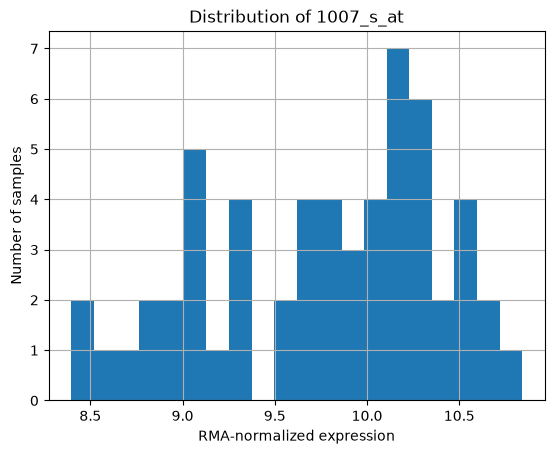

In [9]:
expression[gene_cols[0]].hist(bins=20)
plt.xlabel("RMA-normalized expression")
plt.ylabel("Number of samples")
plt.title(f"Distribution of {gene_cols[0]}")
plt.show()

## 2.3 Biological outcome structure

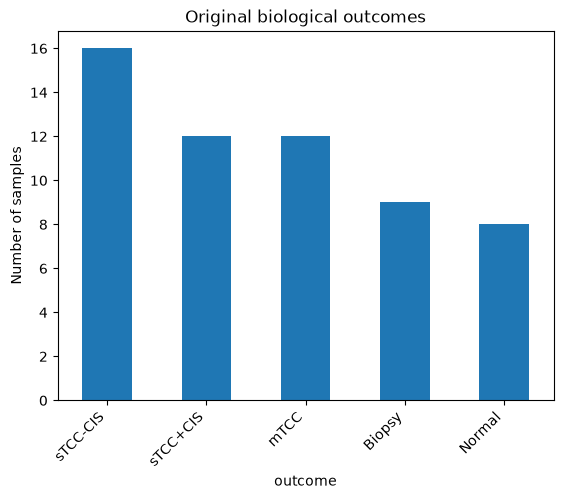

In [11]:
metadata["outcome"].value_counts().plot(kind="bar")
plt.ylabel("Number of samples")
plt.title("Original biological outcomes")
plt.xticks(rotation=45, ha="right")
plt.show()

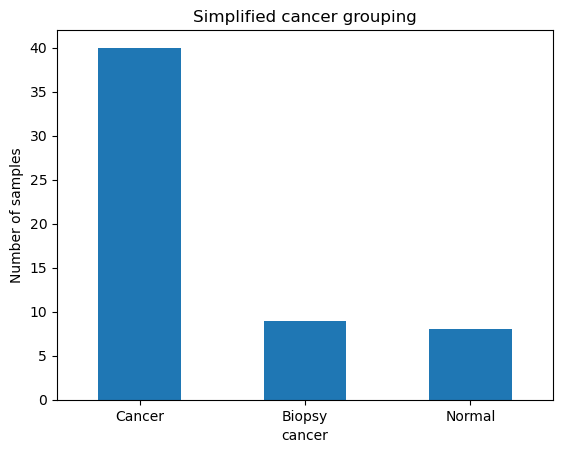

In [18]:
metadata["cancer"].value_counts().plot(kind="bar")
plt.ylabel("Number of samples")
plt.title("Simplified cancer grouping")
plt.xticks(rotation=0)
plt.show()

### Discussion

Why might the original `outcome` and simplified `cancer` variables be useful for different questions?

# 3. Data diagnostics

A diagnostic workflow does **not** mean that we must discover corrupted data.

Real datasets should be checked systematically even when they appear clean.

## 3.1 Are sample identifiers unique?

In [12]:
print("Expression IDs unique:", expression["sample_id"].is_unique)
print("Metadata IDs unique:", metadata["sample_id"].is_unique)

Expression IDs unique: True
Metadata IDs unique: True


## 3.2 Do both tables contain the same samples?

In [13]:
expr_ids = set(expression["sample_id"])
meta_ids = set(metadata["sample_id"])

print("Expression only:", expr_ids - meta_ids)
print("Metadata only:", meta_ids - expr_ids)

Expression only: set()
Metadata only: set()


## 3.4 Exact duplicate samples

In [22]:
print("Duplicate metadata rows:", metadata.duplicated().sum())
print("Duplicate expression rows:", expression.duplicated().sum())

Duplicate metadata rows: 0
Duplicate expression rows: 0


We can also ask whether any two expression rows are numerically identical.

In [23]:
expr_only = expression.set_index("sample_id")
print("Duplicated expression profiles:",
      expr_only.duplicated().sum())

Duplicated expression profiles: 0


## 3.5 Constant and low-variance features

In [24]:
variances = expression[gene_cols].var()

print("Constant features:", (variances == 0).sum())
print("Median feature variance:", variances.median())

Constant features: 0
Median feature variance: 0.1868963225451368


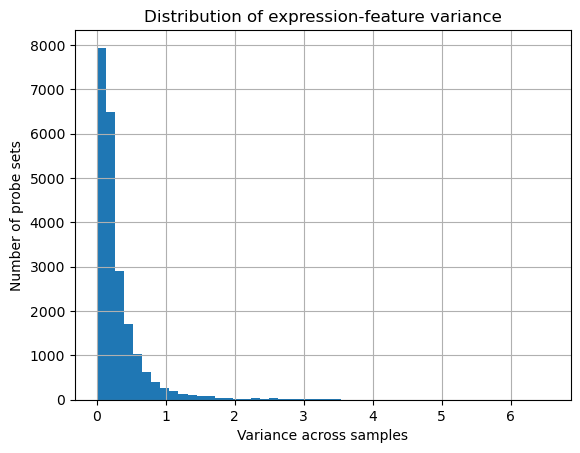

In [25]:
variances.hist(bins=50)
plt.xlabel("Variance across samples")
plt.ylabel("Number of probe sets")
plt.title("Distribution of expression-feature variance")
plt.show()


# 4. Data preparation

## 4.1 Merge measurements and metadata

Because both tables should have one row per sample, we can enforce a one-to-one relationship.

In [14]:
df_real = metadata.merge(
    expression,
    on="sample_id",
    validate="one_to_one")

print(df_real.shape)
df_real.iloc[:5, :10]



(57, 22288)


,sample_id,sample,outcome,batch,cancer,1007_s_at,1053_at,117_at,121_at,1255_g_at
0,GSM71019.CEL,1,Normal,3,Normal,10.115170,5.345168,6.348024,8.901739,3.967672
1,GSM71020.CEL,2,Normal,2,Normal,8.628044,5.063598,6.663625,9.439977,4.466027
2,GSM71021.CEL,3,Normal,2,Normal,8.779235,5.113116,6.465892,9.540738,4.144885
3,GSM71022.CEL,4,Normal,3,Normal,9.248569,5.179410,6.116422,9.254368,4.189338
4,GSM71023.CEL,5,Normal,3,Normal,10.256841,5.181383,5.980457,8.798086,4.078509


## 4.2 Define a possible target

For demonstration, we will use the simplified `cancer` variable as the candidate target.

In [15]:
y_real = df_real["cancer"].copy()
y_real.value_counts()

cancer
Cancer    40
Biopsy     9
Normal     8
Name: count, dtype: int64

## 4.3 Define the real feature matrix

In [16]:
X_real = df_real[gene_cols].copy()

print("X:", X_real.shape)
print("y:", y_real.shape)

X: (57, 22283)
y: (57,)


Notice what is **not** in `X_real`:

- `sample_id`;
- `sample`;
- `outcome`;
- `batch`;
- `cancer`.

Some are identifiers, one is our target, and others are metadata whose inclusion would change the scientific question.




# 5. Artificial within-group similarity for the splitting exercise

The original bladderbatch samples are real biological samples, but the dataset does not provide the repeated-subject structure we want for this exercise. 

We will therefore construct **one pseudo-replicate per real sample** to intentioanlly spoil perfectly good dataset;)

For each real expression profile x_i, we create:

x_i_p = x_i + epsilon

epsilon - small noise

The pseudo-replicate is therefore **highly similar** to its source sample.

## 5.1 Generate pseudo-replicates

In [18]:
rng = np.random.default_rng(RANDOM_STATE)

real = df_real.copy()
real["source_sample_id"] = real["sample_id"]
real["p_group"] = "TG_" + real["sample_id"].astype(str)


pseudo = df_real.copy()
pseudo["source_sample_id"] = pseudo["sample_id"]
pseudo["p_group"] = "TG_" + pseudo["sample_id"].astype(str)


# Give pseudo-replicates unique row/sample identifiers.
pseudo["sample_id"] = pseudo["sample_id"].astype(str) + "_pseudo"

# Small noise relative to the scale ofexpression.
noise_sigma = 0.05
noise = rng.normal(loc=0, scale=noise_sigma, size=(len(pseudo), len(gene_cols)))

pseudo.loc[:, gene_cols] = (pseudo[gene_cols].to_numpy() + noise)

df = pd.concat([real, pseudo], ignore_index=True)

print("Original samples:", len(real))
print("Pseudo-replicates:", len(pseudo))
print("pseudo rows:", len(df))
print("pseudo groups:", df["p_group"].nunique())

Original samples: 57
Pseudo-replicates: 57
pseudo rows: 114
pseudo groups: 57


### Important provenance rule

In [ ]:
df[["sample_id", "source_sample_id", "p_group",  "cancer", "batch"]].head(100)

,sample_id,source_sample_id,p_group,replicate_type,cancer,batch
0,GSM71019.CEL,GSM71019.CEL,TG_GSM71019.CEL,real,Normal,3
1,GSM71020.CEL,GSM71020.CEL,TG_GSM71020.CEL,real,Normal,2
2,GSM71021.CEL,GSM71021.CEL,TG_GSM71021.CEL,real,Normal,2
3,GSM71022.CEL,GSM71022.CEL,TG_GSM71022.CEL,real,Normal,3
4,GSM71023.CEL,GSM71023.CEL,TG_GSM71023.CEL,real,Normal,3
...,...,...,...,...,...,...
95,GSM71059.CEL_pseudo,GSM71059.CEL,TG_GSM71059.CEL,pseudo,Cancer,2
96,GSM71060.CEL_pseudo,GSM71060.CEL,TG_GSM71060.CEL,pseudo,Cancer,1
97,GSM71061.CEL_pseudo,GSM71061.CEL,TG_GSM71061.CEL,pseudo,Cancer,5
98,GSM71062.CEL_pseudo,GSM71062.CEL,TG_GSM71062.CEL,pseudo,Cancer,5


`source_sample_id`, and `p_group` are synthetic metadata.

The original `batch`, `outcome`, and `cancer` values remain those of the real sample.

## 5.2 Verify within-group similarity

Calculate the correlation between every real sample and its pseudo-replicate.

In [19]:
pair_correlations = []

for group, group_df in df.groupby("p_group"):
    if len(group_df) != 2:
        continue

    a = group_df.iloc[0][gene_cols].to_numpy(dtype=float)
    b = group_df.iloc[1][gene_cols].to_numpy(dtype=float)

    pair_correlations.append(np.corrcoef(a, b)[0, 1])

pair_correlations = pd.Series(pair_correlations)

pair_correlations

0     0.999536
1     0.999382
2     0.999408
3     0.999448
4     0.999530
5     0.999606
6     0.999439
7     0.999417
8     0.999651
9     0.999509
10    0.999615
11    0.999612
12    0.999611
13    0.999546
14    0.999642
15    0.999626
16    0.999595
17    0.999625
18    0.999619
19    0.999602
20    0.999630
21    0.999620
22    0.999591
23    0.999668
24    0.999521
25    0.999598
26    0.999631
27    0.999546
28    0.999624
29    0.999516
30    0.999614
31    0.999536
32    0.999578
33    0.999621
34    0.999633
35    0.999571
36    0.999576
37    0.999591
38    0.999622
39    0.999656
40    0.999631
41    0.999634
42    0.999659
43    0.999621
44    0.999561
45    0.999625
46    0.999635
47    0.999631
48    0.999566
49    0.999536
50    0.999519
51    0.999532
52    0.999485
53    0.999386
54    0.999549
55    0.999519
56    0.999290
dtype: float64

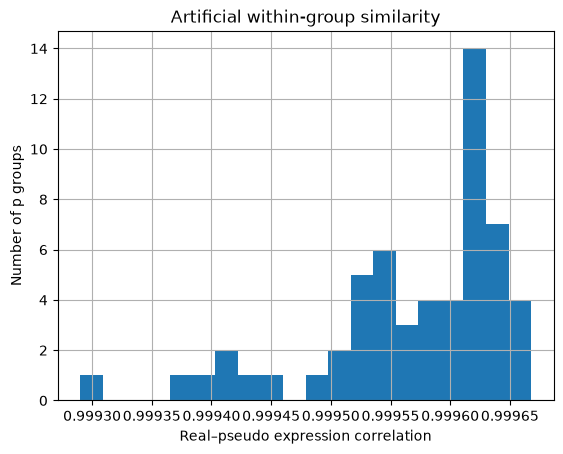

In [20]:
pair_correlations.hist(bins=20)
plt.xlabel("Real–pseudo expression correlation")
plt.ylabel("Number of p groups")
plt.title("Artificial within-group similarity")
plt.show()

## 5.3 Introduce synthetic missing values (pseudoNA)
To spoil our good dataset even more we will intoduce some NA.
We alter expression measurements only; sample identifiers, metadata, targets, and grouping variables remain available for the exercise.

In [21]:
pseudo_na_rng = np.random.default_rng(RANDOM_STATE + 1)

df_pseudona = df.copy()
expression_values = df_pseudona[gene_cols].to_numpy(dtype=float).copy()

# Remove 0.01% of expression cells

pseudo_na_fraction = 0.0001
n_expression_cells = expression_values.size
n_pseudona = max(1, int(round(n_expression_cells * pseudo_na_fraction)))
flat_indices = pseudo_na_rng.choice(
    n_expression_cells,
    size=n_pseudona,
    replace=False
)
rows, columns = np.unravel_index(
    flat_indices,
    expression_values.shape
)
expression_values[rows, columns] = np.nan
df_pseudona.loc[:, gene_cols] = expression_values

print("pseudo rows:", len(df_pseudona))
print("Synthetic missing expression cells:", df_pseudona[gene_cols].isna().sum().sum())

pseudo rows: 114
Synthetic missing expression cells: 254


## 5.4 Missing-value handling: detection, removal, and imputation

Missing values should be handled as part of the data-generating and modelling workflow. Start by detecting where they occur and how much information is affected.

There is no universally correct response:

- **Detection:** inspect missingness by table, row, column, and experimental group.
- **Removal:** remove rows or features only when the loss is acceptable and the rule is scientifically justified. In high-dimensional data, dropping every row with any missing feature can discard most observations.
- **Imputation:** replace missing values using a rule such as a median, mean, K-nearest neighbours, or a model-based method. The imputation rule must be fitted on the training data only, then applied to the test data, so that test-set information does not leak into training.

The following cells are a demonstration using the synthetic pseudoNA copy.

In [22]:
missing_by_column = df_pseudona[gene_cols].isna().sum()
missing_by_row = df_pseudona[gene_cols].isna().sum(axis=1)

print("Total missing expression cells:", int(missing_by_column.sum()))
print("Features with at least one missing value:", int((missing_by_column > 0).sum()))
print("Rows with at least one missing value:", int((missing_by_row > 0).sum()))

display(missing_by_column[missing_by_column > 0].head())
missing_by_row.describe()

Total missing expression cells: 254
Features with at least one missing value: 253
Rows with at least one missing value: 104


200021_at      1
200070_at      1
200829_x_at    1
200905_x_at    1
200984_s_at    1
dtype: int64

count    114.000000
mean       2.228070
std        1.376382
min        0.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        7.000000
dtype: float64

### Removal as a possible strategy

Complete-row removal is easy to write, but it can be very costly. Feature removal is another option, although removing a feature because of one missing value may also discard useful measurements. Compare both consequences before choosing a rule.

In [46]:
df_rows_removed = df_pseudona.dropna(subset=gene_cols)
features_without_missing = [
    column for column in gene_cols
    if df_pseudona[column].notna().all()
]
X_features_removed = df_pseudona[features_without_missing].copy()

print("Rows before removal:", len(df_pseudona))
print("Rows after complete-row removal:", len(df_rows_removed))
print("Features before removal:", len(gene_cols))
print("Features after removal of any incomplete feature:", X_features_removed.shape[1])

Rows before removal: 114
Rows after complete-row removal: 15
Features before removal: 22283
Features after removal of any incomplete feature: 22030


### Imputation as a possible strategy

Here we use median imputation as a simple baseline. In a real analysis, the choice should reflect the measurement process and the scientific question. 

In [23]:

X_pseudona = df_pseudona[gene_cols].copy()

imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(imputer.fit_transform(X_pseudona), columns=gene_cols)


X_imputed.isna().sum().sum()

np.int64(0)

# 6. Splits

## 6.1 Naive random row-wise split

In [24]:
row_indices = np.arange(len(df))

train_idx_random, test_idx_random = train_test_split(
    row_indices,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=df["cancer"])

random_train = df.iloc[train_idx_random]
random_test = df.iloc[test_idx_random]

Lets check if some pseudo groups is present in both sets

In [25]:
random_train_groups = set(random_train["p_group"])
random_test_groups = set(random_test["p_group"])

leaked_groups = random_train_groups & random_test_groups

print("Groups appearing in both train and test", len(leaked_groups))

list(sorted(leaked_groups))

Groups appearing in both train and test 25


['TG_GSM71019.CEL',
 'TG_GSM71021.CEL',
 'TG_GSM71023.CEL',
 'TG_GSM71024.CEL',
 'TG_GSM71028.CEL',
 'TG_GSM71029.CEL',
 'TG_GSM71037.CEL',
 'TG_GSM71038.CEL',
 'TG_GSM71041.CEL',
 'TG_GSM71043.CEL',
 'TG_GSM71046.CEL',
 'TG_GSM71047.CEL',
 'TG_GSM71048.CEL',
 'TG_GSM71056.CEL',
 'TG_GSM71059.CEL',
 'TG_GSM71062.CEL',
 'TG_GSM71064.CEL',
 'TG_GSM71066.CEL',
 'TG_GSM71067.CEL',
 'TG_GSM71068.CEL',
 'TG_GSM71069.CEL',
 'TG_GSM71072.CEL',
 'TG_GSM71075.CEL',
 'TG_GSM71076.CEL',
 'TG_GSM71077.CEL']

These rows are not independent. A pseudo-replicate in the test set may be almost identical to its source sample in training.


## 6.2 Group-aware split

In [26]:
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=RANDOM_STATE)

train_idx, test_idx = next(
    splitter.split(
        df[gene_cols],
        df["cancer"],
        groups=df["p_group"]))

train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

In [27]:
train_groups = set(train_df["p_group"])
test_groups = set(test_df["p_group"])

print("Group overlap", train_groups & test_groups)

Group overlap set()


Expected:

```text
set()
```

## 6.3 Verify that each original/pseudo pair stays together

In [61]:
split_membership = pd.Series("test", index=df.index)
split_membership.iloc[train_idx] = "train"

check = (
    df.assign(split=split_membership)
      .groupby("p_group")["split"]
      .nunique())

print("Groups split across partitions",(check > 1).sum())

Groups split across partitions 0


### Discussion

For the artificial pseud data, `p_group` plays the role that variables such as these often play in real studies:

- patient ID;
- donor ID;
- animal ID;
- family;
- experimental unit;
- repeated-measure subject;
- original image before augmentation;
- original molecule before generating conformers.

# 7. Real batch effects and confounding

Now we return to a property that is **not synthetic**.

`batch` is real metadata from the bladderbatch experiment and reflects the dates on which microarrays were processed.

## 7.1 Examine the experimental design

Use **only the real samples** here so that our pseudo-replicates do not alter counts.

In [ ]:
pd.crosstab(real["batch"], real["cancer"],margins=True)

cancer,Biopsy,Cancer,Normal,All
batch,,,,
1,0,11,0,11
2,0,14,4,18
3,0,0,4,4
4,5,0,0,5
5,4,15,0,19
All,9,40,8,57


In [ ]:
pd.crosstab(real["batch"], real["cancer"], normalize="index").round(2)

cancer,Biopsy,Cancer,Normal
batch,,,
1,0.00,1.00,0.00
2,0.00,0.78,0.22
3,0.00,0.00,1.00
4,1.00,0.00,0.00
5,0.21,0.79,0.00


### Question

Is biological class independent of processing batch?

## 7.2 Original outcomes by batch

In [28]:
outcome_batch = pd.crosstab(real["batch"], real["outcome"])

outcome_batch

outcome,Biopsy,Normal,mTCC,sTCC+CIS,sTCC-CIS
batch,,,,,
1,0,0,11,0,0
2,0,4,1,0,13
3,0,4,0,0,0
4,5,0,0,0,0
5,4,0,0,12,3


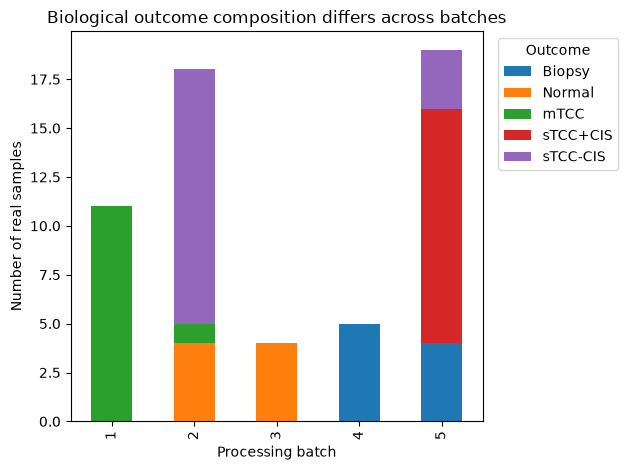

In [29]:
outcome_batch.plot(kind="bar", stacked=True)

plt.xlabel("Processing batch")
plt.ylabel("Number of real samples")
plt.title("Biological outcome composition differs across batches")
plt.legend(title="Outcome", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# 8. Visualizing batch structure

We will use PCA only as a **diagnostic visualization** here.

The mathematical details of PCA will be covered in a later practical.

## 8.1 Select highly variable features for visualization

Using all 22,283 features is unnecessary for a quick exploratory plot. So we will keep only top 1000 by variation

In [30]:
real_X = real[gene_cols]

feature_variance = real_X.var().sort_values(ascending=False)
top_genes = feature_variance.head(1000).index

X_vis = real_X[top_genes]

## 8.2 Standardize and project to two dimensions

In [31]:
X_scaled = StandardScaler().fit_transform(X_vis)

pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": coords[:, 0],
    "PC2": coords[:, 1],
    "batch": real["batch"].astype(str).values,
    "cancer": real["cancer"].astype(str).values,
    "outcome": real["outcome"].astype(str).values
})

print(
    "Explained variance:",
    pca.explained_variance_ratio_.round(3)
)

Explained variance: [0.279 0.166]


## 8.3 Color by batch

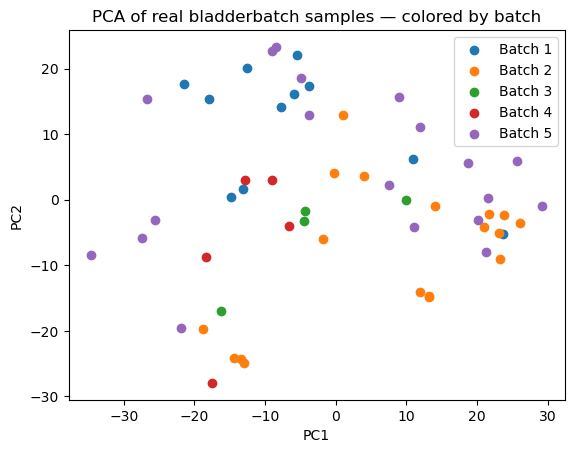

In [70]:
for batch, group in pca_df.groupby("batch"):
    plt.scatter(
        group["PC1"],
        group["PC2"],
        label=f"Batch {batch}"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of real bladderbatch samples — colored by batch")
plt.legend()
plt.show()

## 8.4 Color by cancer class

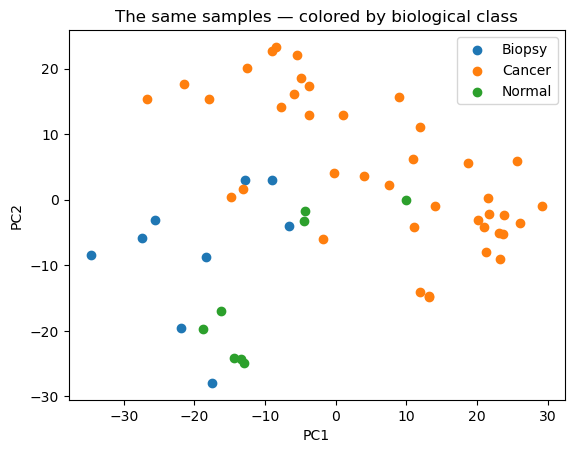

In [71]:
for label, group in pca_df.groupby("cancer"):
    plt.scatter(
        group["PC1"],
        group["PC2"],
        label=label
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("The same samples — colored by biological class")
plt.legend()
plt.show()

### Discussion

Look at the **same geometric arrangement** twice:

1. colored by processing batch;
2. colored by biological target.

If batch and target are associated, how confidently can we interpret a predictive signal as biology?

# 9. Prepare ML-ready train and test sets

Return to the group-aware split.

In [72]:
X_train = train_df[gene_cols].copy()
X_test = test_df[gene_cols].copy()

y_train = train_df["cancer"].copy()
y_test = test_df["cancer"].copy()

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (84, 22283)
X_test: (30, 22283)
y_train: (84,)
y_test: (30,)


Check missingness before proceeding.

In [73]:
print("Missing train values:",
      X_train.isna().sum().sum())

print("Missing test values:",
      X_test.isna().sum().sum())

Missing train values: 0
Missing test values: 0


At this point we have demonstrated how an ML-ready dataset is constructed.

We deliberately stop before fitting a predictive model.

# 10. What was real and what was synthetic?

| Component | Provenance | Purpose |
|---|---|---|
| Microarray expression | **Real** | Biological measurement |
| `outcome` | **Real** | Original biological class |
| `cancer` | **Real** | Simplified biological class |
| `batch` | **Real** | Processing batch |
| 57 original samples | **Real** | Biological observations |
| Pseudo-replicate expression | **Synthetic derivative** | Grouping/leakage demonstration |
| `p_group` | **Synthetic** | Group-aware splitting |
| `replicate_type` | **Synthetic** | Track provenance |




# 11. Independent task - UCI Mice Protein Expression

Now apply the same general workflow to the UCI Mice Protein Expression dataset.

The instructor will provide:

    Data_Cortex_Nuclear.xls

The dataset is available from the UCI Machine Learning Repository at:
https://archive.ics.uci.edu/dataset/342/mice%2Bprotein%2Bexpression

The dataset contains 1,080 rows, expression levels for 77 proteins or protein modifications, measurements from 72 mice, and 15 measurements per mouse. It also includes MouseID, Genotype, Treatment, Behavior, and an eight-level composite class.

For this practical, treat MouseID as the independent biological unit when asking whether a model generalizes to new mice. The repeated measurements from one mouse must stay in the same partition. The UCI dataset also contains real missing values, so your workflow must make the NA decision explicit.

Your goal is to turn the data into a defensible ML-ready dataset while keeping measurement, mouse, experimental-condition, and target roles separate.

## Required tasks

### A. Data presentation

Identify:

- what one row represents and what one biological mouse represents;
- the 77 numerical protein-expression measurements;
- MouseID and the experimental metadata;
- one possible prediction target.

Consider Genotype as a primary target: control versus trisomy. You may choose the eight-level class target instead, but explain why. Remember that class is constructed from genotype, behavior, and treatment.

### B. EDA and tidy-data assessment

- load the Excel file and inspect dimensions, column names, and data types;
- inspect the distributions of Genotype, Treatment, Behavior, and class;
- check how many rows and how many unique mice belong to each group;
- visualize at least three biologically meaningful relationships.

Possible plots include:

- distributions of selected protein measurements by genotype;
- a PCA or two-dimensional projection colored by genotype, treatment, or behavior;
- protein-expression relationships or a correlation heatmap;
- the number of measurements per MouseID.

For every plot, state the biological question it addresses.

### C. Diagnostics

Check:

- missingness in the protein measurements and metadata;
- duplicate rows and duplicate MouseID-measurement records;
- whether every mouse has the expected number of repeated measurements;
- unusual categories or inconsistent labels;
- non-finite, negative, or otherwise implausible expression values;
- highly correlated or redundant protein variables;
- whether any candidate predictor is a deterministic part of the target.

### D. Preparation

Choose one supervised-learning problem and create:

    X
    y

Explain every variable that you exclude.

For a genotype-prediction question, start with the 77 protein measurements as candidate features. Exclude:

- MouseID, because it identifies the biological unit and can cause leakage;
- the target column;
- class when Genotype is the target, because it contains genotype information;
- Treatment and Behavior unless you explicitly want a conditional prediction question and can justify their use.

Use the real missing values in the dataset to compare a defensible removal rule with an imputation rule. If you impute, fit the imputer on the training data only and apply it to the test data.

### E. Split

Create an appropriate training/test split.

For generalization to unseen mice:

- group by MouseID;
- keep all 15 measurements from a mouse in the same partition;
- use a group-aware split such as GroupShuffleSplit or StratifiedGroupKFold when appropriate.

Explain:

- what population you want the model to generalize to;
- why a row-wise random split would give an over-optimistic estimate;
- what the independent biological unit is;
- whether stratification is needed and whether it is compatible with your grouping strategy.

### F. Confounding and distribution structure

Investigate associations between the target and:

- treatment;
- behavior;
- genotype;
- the composite class;
- the number of measurements per mouse.

Use cross-tabulations and plots to ask:

- are treatment and behavior balanced across genotype?
- does the composite class encode the target directly?
- do some mice or experimental groups contribute different numbers of rows?
- could a model exploit experimental design structure instead of protein biology?

Identify at least one plausible source of confounding, target leakage, or distribution shift.

### G. Deliverable

Provide:

- X_train, X_test, y_train, y_test;
- a table documenting the role of each column;
- a missingness report and a justified removal or imputation decision;
- plots if you want;
- a short Markdown interpretation describing:
  - the ML question;
  - the biological unit;
  - the split strategy;
  - one potential source of bias, confounding, or leakage.

## Optional advanced task

Compare two evaluation questions:

1. a random row-wise train/test split;
2. a mouse-grouped train/test split.

Are these evaluating the same kind of generalization?

As a second extension, compare predicting Genotype with predicting the composite class. Which question is biologically clearer, and which variables must be excluded to avoid target leakage?


# 12. Take-home messages

- Biological data should be understood before they are modelled.
- High-dimensional omics commonly have \(p \gg n\).
- Metadata are part of the scientific problem, not administrative decoration.
- Data diagnostics include checking experimental structure, not only detecting `NaN`.
- Similar or repeated observations must remain in the same split.
- Data augmentation and pseudo-replication can produce leakage if derivatives cross the split boundary.
- Batch effects are technical signals that a model can exploit.
- Batch–target confounding makes biological interpretation especially difficult.
- Train/test splitting is part of experimental design.
- A valid ML pipeline begins with a valid scientific question.

# 13. Data-preparation readiness checklist

Use this checklist before starting any biological machine-learning analysis. Tick an item only after inspecting the data or documenting a justified decision. It is dataset-independent and can be reused in later practicals.

## Scientific purpose and provenance

- [ ] Is the biological question and prediction task stated clearly?
- [ ] Is the unit of observation clear (for example, patient, tissue, cell, mouse, or technical measurement)?
- [ ] Do I know where the data came from, how they were generated, and under which license or access conditions they may be used?
- [ ] Have I recorded the data version, processing history, and transformations already applied?

## Table shape and identifiers

- [ ] Is the table tidy: one observation per row, one variable per column, and one value per cell?
- [ ] If the original assay has features in rows and samples in columns, have I transposed it into the format expected by the analysis tool?
- [ ] Are row names, column names, and identifiers clear, unique, stable, and free from accidental index columns?
- [ ] Can every feature and observation be traced back to its source?
- [ ] Are the feature matrix and metadata aligned by an explicit identifier rather than by row order?

## Types, values, and measurement meaning

- [ ] Are numerical, categorical, ordinal, text, date, and identifier columns correctly classified?
- [ ] Are units, scales, encodings, reference categories, and detection limits understood?
- [ ] Have I checked impossible values, inconsistent labels, unexpected categories, constant features, and extreme values?
- [ ] Are normalization, scaling, log transformation, and batch-correction steps documented?

## Missing values

- [ ] Have I detected missing values using the dataset's actual missing-value representations, not only `NaN`?
- [ ] Have I measured missingness by row, column, group, and relevant batch or time variable?
- [ ] Do I know whether missingness is structural, technical, or plausibly related to the biology or target?
- [ ] Have I justified whether to retain, remove, or impute missing values?
- [ ] If imputing, will the imputer be fitted on training data only and then applied to validation/test data?

## Replicates, dependence, and grouping

- [ ] Have I checked for exact duplicates and near-duplicate observations?
- [ ] Are observations biological replicates, technical replicates, repeated measurements, pseudo-replicates, or independent samples?
- [ ] Is the independent biological unit identified by a grouping variable?
- [ ] Will all related observations and their derivatives remain in the same train/validation/test split?
- [ ] If I created augmented or synthetic observations, is their provenance recorded and reproducible?

## Target, leakage, and study design

- [ ] Is the target defined before modelling, with its classes or values checked for balance and validity?
- [ ] Have I excluded identifiers, post-outcome variables, duplicated target information, and other leakage sources from the features?
- [ ] Have I identified batch, site, plate, subject, cohort, treatment, sex, age, time, or other possible confounders?
- [ ] Have I checked whether the target is associated with a technical or grouping variable?
- [ ] Does the planned split represent the biological generalization question?

## Reproducibility and decision record

- [ ] Are random seeds, software versions, file names, and input/output shapes recorded?
- [ ] Are all preprocessing steps placed in a reproducible pipeline?
- [ ] Have I recorded unresolved data-quality concerns and the decisions made about them?
- [ ] Can another person explain what each row, column, feature, target, and grouping variable means?

## Short preparation summary

Before modelling, write down:

- biological unit: ...
- number of observations and features: ...
- target and feature definition: ...
- missing-value decision: ...
- replicate/grouping decision: ...
- main confounder or possible leakage source: ...
- train/test split and why it is appropriate: ...
- remaining concerns: ...

In [4]:
# Open and inspect dataset

mice_dataset = pd.read_excel('Data_Cortex_Nuclear.xls')
mice_dataset.head()

,MouseID,DYRK1A_N,ITSN1_N,BDNF_N,NR1_N,NR2A_N,pAKT_N,pBRAF_N,pCAMKII_N,pCREB_N,...,pCFOS_N,SYP_N,H3AcK18_N,EGR1_N,H3MeK4_N,CaNA_N,Genotype,Treatment,Behavior,class
0,309_1,0.503644,0.747193,0.430175,2.816329,5.990152,0.218830,0.177565,2.373744,0.232224,...,0.108336,0.427099,0.114783,0.131790,0.128186,1.675652,Control,Memantine,C/S,c-CS-m
1,309_2,0.514617,0.689064,0.411770,2.789514,5.685038,0.211636,0.172817,2.292150,0.226972,...,0.104315,0.441581,0.111974,0.135103,0.131119,1.743610,Control,Memantine,C/S,c-CS-m
2,309_3,0.509183,0.730247,0.418309,2.687201,5.622059,0.209011,0.175722,2.283337,0.230247,...,0.106219,0.435777,0.111883,0.133362,0.127431,1.926427,Control,Memantine,C/S,c-CS-m
3,309_4,0.442107,0.617076,0.358626,2.466947,4.979503,0.222886,0.176463,2.152301,0.207004,...,0.111262,0.391691,0.130405,0.147444,0.146901,1.700563,Control,Memantine,C/S,c-CS-m
4,309_5,0.434940,0.617430,0.358802,2.365785,4.718679,0.213106,0.173627,2.134014,0.192158,...,0.110694,0.434154,0.118481,0.140314,0.148380,1.839730,Control,Memantine,C/S,c-CS-m


In [5]:
mice_dataset.shape

(1080, 82)

In [ ]:
# Inspect metadata cols
mice_dataset[['MouseID', 'Genotype', 'Treatment', 'Behavior', 'class']].info()

<class 'pandas.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   MouseID    1080 non-null   str  
 1   Genotype   1080 non-null   str  
 2   Treatment  1080 non-null   str  
 3   Behavior   1080 non-null   str  
 4   class      1080 non-null   str  
dtypes: str(5)
memory usage: 42.3 KB


In [7]:
mice_dataset['Treatment'].value_counts()

Treatment
Memantine    570
Saline       510
Name: count, dtype: int64

In [ ]:
# Inspect classes and samples/replicates distribution among them
mice_dataset['class'].value_counts()

class
c-CS-m    150
c-SC-m    150
c-CS-s    135
c-SC-s    135
t-CS-m    135
t-SC-m    135
t-SC-s    135
t-CS-s    105
Name: count, dtype: int64

In [67]:
mice_dataset['Genotype'].value_counts()

Genotype
Control    570
Ts65Dn     510
Name: count, dtype: int64

In [9]:
mice_dataset['Mouse_Base_ID'] = mice_dataset['MouseID'].str.split('_').str[0]

# Number of unique mouse ID
n_unique_mice = mice_dataset['Mouse_Base_ID'].nunique()
print(f"Unique mice: {n_unique_mice}")

Unique mice: 72


In [10]:
mice_dataset['Mouse_Base_ID'].unique()

array(['309', '311', '320', '321', '322', '3415', '3499', '3507', '3520',
       '3521', '294', '3412', '3413', '3419', '3420', '3500', '3503',
       '362', '364', '365', '3477', '3478', '3479', '3480', '3484',
       '3497', '50810A', '50810D', '50810F', '3422', '3423', '3424',
       '3481', '3488', '3489', '3490', '3516', 'J2292', '3414', '3416',
       '3417', '3429', '3504', '3505', '3522', '361', '363', '293',
       '3411', '3418', '3501', '3502', '3530', '3534', '3605', '3606',
       '18899', '3476', '3483', '3498', '50810B', '50810C', '50810E',
       '3421', '3425', '3426', '3491', '3513', '3517', '3525', 'J1291',
       'J3295'], dtype=object)

In [11]:
# Check if number of replicates is consistent
replicates_per_mouse = mice_dataset.groupby('Mouse_Base_ID').size()
assert (replicates_per_mouse == 15).all(), "Some mice dont have same num of replicates"

In [14]:
# Check if meta cols are the same for all replicates belonging to 1 mouse
meta_cols = ['Genotype', 'Treatment', 'Behavior', 'class']
meta_check = mice_dataset.groupby('Mouse_Base_ID')[meta_cols].nunique()
assert (meta_check == 1).all().all(), 'Metadata is inconsistent across replicates'

In [15]:
# Add dilutions and tech replicate IDs (decompose MouseID)
mice_dataset['Dilution'] = (mice_dataset['MouseID'].str.split('_').str[1].astype(int) - 1) // 3 + 1
mice_dataset['Tech_Rep'] = (mice_dataset['MouseID'].str.split('_').str[1].astype(int) - 1) % 3 + 1

mice_dataset.head(30)

,MouseID,DYRK1A_N,ITSN1_N,BDNF_N,NR1_N,NR2A_N,pAKT_N,pBRAF_N,pCAMKII_N,pCREB_N,...,EGR1_N,H3MeK4_N,CaNA_N,Genotype,Treatment,Behavior,class,Mouse_Base_ID,Dilution,Tech_Rep
0,309_1,0.503644,0.747193,0.430175,2.816329,5.990152,0.218830,0.177565,2.373744,0.232224,...,0.131790,0.128186,1.675652,Control,Memantine,C/S,c-CS-m,309,1,1
1,309_2,0.514617,0.689064,0.411770,2.789514,5.685038,0.211636,0.172817,2.292150,0.226972,...,0.135103,0.131119,1.743610,Control,Memantine,C/S,c-CS-m,309,1,2
2,309_3,0.509183,0.730247,0.418309,2.687201,5.622059,0.209011,0.175722,2.283337,0.230247,...,0.133362,0.127431,1.926427,Control,Memantine,C/S,c-CS-m,309,1,3
3,309_4,0.442107,0.617076,0.358626,2.466947,4.979503,0.222886,0.176463,2.152301,0.207004,...,0.147444,0.146901,1.700563,Control,Memantine,C/S,c-CS-m,309,2,1
4,309_5,0.434940,0.617430,0.358802,2.365785,4.718679,0.213106,0.173627,2.134014,0.192158,...,0.140314,0.148380,1.839730,Control,Memantine,C/S,c-CS-m,309,2,2
5,309_6,0.447506,0.628176,0.367388,2.385939,4.807635,0.218578,0.176233,2.141282,0.195188,...,0.140766,0.142180,1.816389,Control,Memantine,C/S,c-CS-m,309,2,3
6,309_7,0.428033,0.573696,0.342709,2.334224,4.473130,0.225173,0.184004,2.012414,0.195789,...,0.156682,0.157499,1.528484,Control,Memantine,C/S,c-CS-m,309,3,1
7,309_8,0.416923,0.564036,0.327703,2.260135,4.268735,0.214834,0.179668,2.007985,0.189803,...,0.155612,0.159409,1.652658,Control,Memantine,C/S,c-CS-m,309,3,2
8,309_9,0.386311,0.538428,0.317720,2.125725,4.063950,0.207222,0.167778,1.861514,0.180684,...,0.152711,0.158235,1.834599,Control,Memantine,C/S,c-CS-m,309,3,3
9,309_10,0.380827,0.499294,0.362462,2.096266,3.598587,0.227649,0.188093,1.717861,0.188093,...,0.188849,0.192334,1.516862,Control,Memantine,C/S,c-CS-m,309,4,1


In [16]:
protein_cols = mice_dataset.columns.difference(['MouseID', 'Mouse_Base_ID', 'Dilution', 'Tech_Rep'] + meta_cols)

In [18]:
# Missing data in meta cols
print("Missing in metadata:", mice_dataset[meta_cols].isnull().sum().to_dict())

Missing in metadata: {'Genotype': 0, 'Treatment': 0, 'Behavior': 0, 'class': 0}


In [19]:
# Unexpected values in protein cols
print("Total missing cell values:", mice_dataset[protein_cols].isnull().sum().sum())
print("Non-finite values:", (~np.isfinite(mice_dataset[protein_cols].select_dtypes(include=np.number))).sum().sum())
print("Negative values:", (mice_dataset[protein_cols] < 0).sum().sum())

Total missing cell values: 1396
Non-finite values: 1396
Negative values: 1


In [29]:
pd.set_option('display.max_columns', None)

In [30]:
# Find negative value
mice_dataset[(mice_dataset[protein_cols] < 0).any(axis=1)]

,MouseID,DYRK1A_N,ITSN1_N,BDNF_N,NR1_N,NR2A_N,pAKT_N,pBRAF_N,pCAMKII_N,pCREB_N,pELK_N,pERK_N,pJNK_N,PKCA_N,pMEK_N,pNR1_N,pNR2A_N,pNR2B_N,pPKCAB_N,pRSK_N,AKT_N,BRAF_N,CAMKII_N,CREB_N,ELK_N,ERK_N,GSK3B_N,JNK_N,MEK_N,TRKA_N,RSK_N,APP_N,Bcatenin_N,SOD1_N,MTOR_N,P38_N,pMTOR_N,DSCR1_N,AMPKA_N,NR2B_N,pNUMB_N,RAPTOR_N,TIAM1_N,pP70S6_N,NUMB_N,P70S6_N,pGSK3B_N,pPKCG_N,CDK5_N,S6_N,ADARB1_N,AcetylH3K9_N,RRP1_N,BAX_N,ARC_N,ERBB4_N,nNOS_N,Tau_N,GFAP_N,GluR3_N,GluR4_N,IL1B_N,P3525_N,pCASP9_N,PSD95_N,SNCA_N,Ubiquitin_N,pGSK3B_Tyr216_N,SHH_N,BAD_N,BCL2_N,pS6_N,pCFOS_N,SYP_N,H3AcK18_N,EGR1_N,H3MeK4_N,CaNA_N,Genotype,Treatment,Behavior,class,Mouse_Base_ID,Dilution,Tech_Rep
298,365_14,0.294966,0.498586,0.317025,2.20871,3.060238,0.2944,0.24095,3.947115,0.231052,1.424208,0.370475,0.374152,0.322681,0.332014,0.82862,0.735577,1.496889,1.307975,0.541007,0.746889,0.323529,0.4375,0.223982,1.008484,2.14112,1.158088,0.280543,0.367081,0.69457,0.222568,0.356618,1.785916,0.700792,0.493495,0.501414,0.864536,0.697964,0.349265,0.590781,0.340215,0.310238,0.379242,0.372738,0.167126,0.889173,0.156693,1.624409,0.283465,0.311614,0.840354,0.110827,-0.062008,0.179331,0.126181,0.174016,0.170472,0.191732,0.126378,0.200787,0.095866,0.719488,0.288976,1.802559,2.349213,0.199409,1.386811,0.969291,0.269094,NaN,NaN,0.126181,0.19626,0.538976,NaN,0.315157,NaN,1.362205,Control,Memantine,S/C,c-SC-m,365,5,2


In [31]:
### Negative value in RRP1_N, MouseID 365_14

In [115]:
row_missing_pct = mice_dataset[protein_cols].isnull().mean(axis=0)
print("Cols with no NAs:", (row_missing_pct == 0).sum(), "out of", len(protein_cols))
print("Cols with < 5% NAs:", (row_missing_pct < 0.05).sum(), "out of", len(protein_cols))

Cols with no NAs: 28 out of 69
Cols with < 5% NAs: 69 out of 69


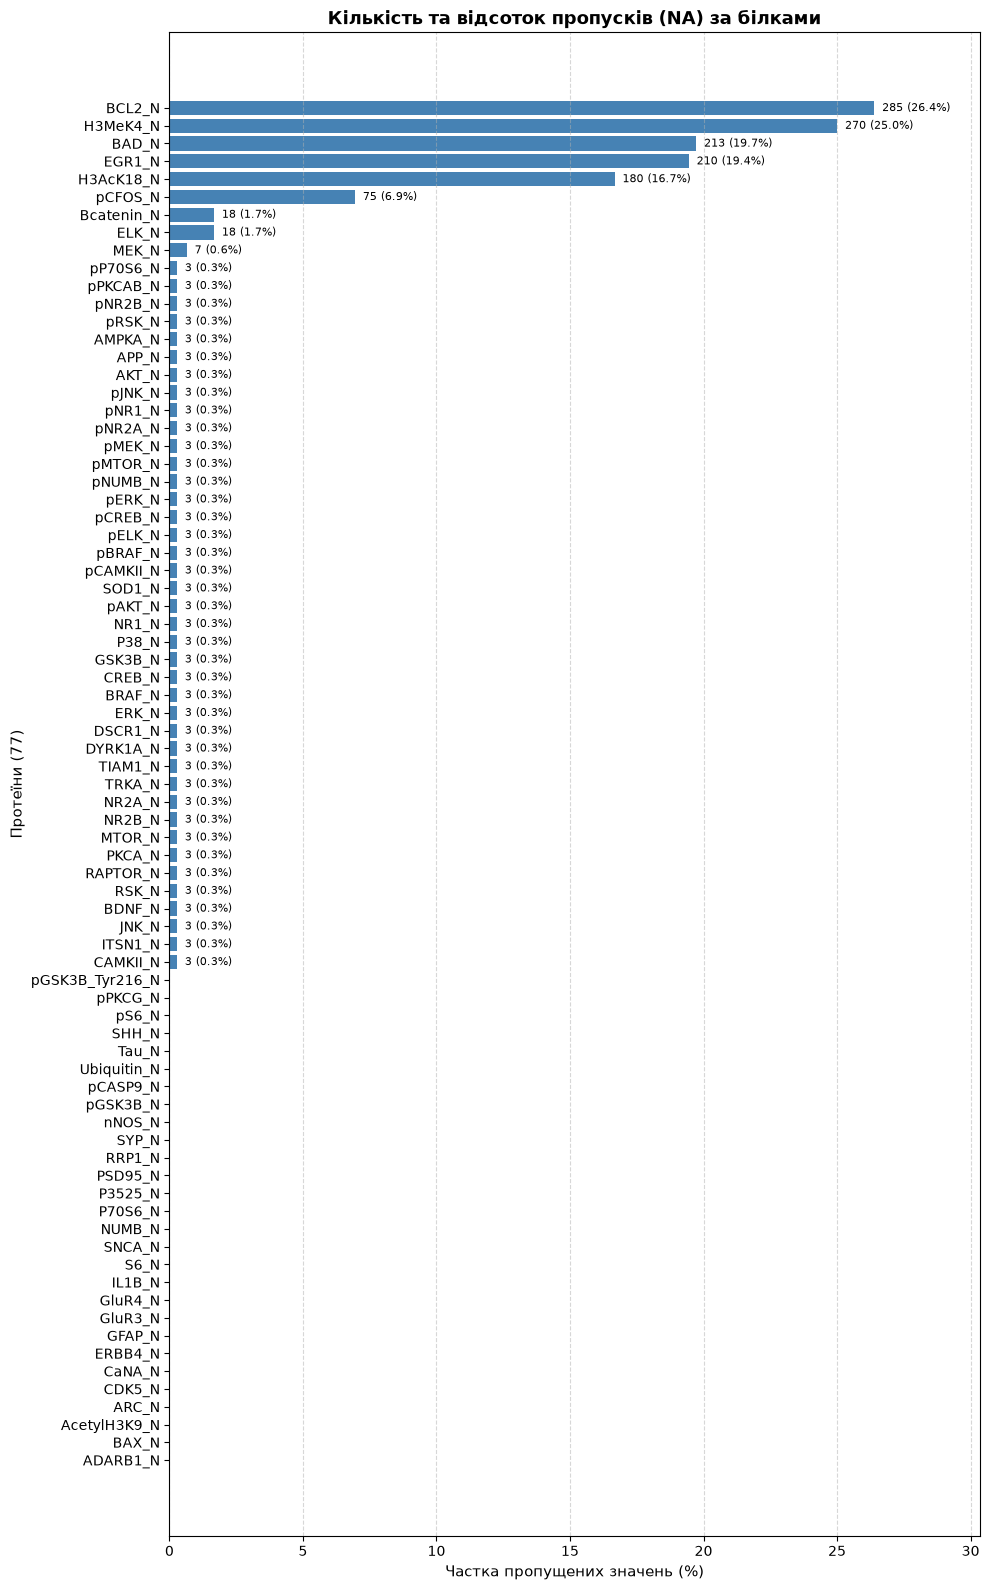

In [34]:
### Plot - AI generated
# 1. Розрахунок кількості та відсотка NA для кожного білка
na_df = pd.DataFrame({
    'na_count': mice_dataset[protein_cols].isnull().sum(),
    'na_pct': mice_dataset[protein_cols].isnull().mean() * 100
}).sort_values(by='na_pct', ascending=True)

# 2. Побудова горизонтального графіку
plt.figure(figsize=(10, 16))
bars = plt.barh(na_df.index, na_df['na_pct'], color='steelblue', edgecolor='none')

# 3. Додавання точних значень кількості NA поруч із кожним стовпчиком
for bar, count, pct in zip(bars, na_df['na_count'], na_df['na_pct']):
    if pct > 0:
        plt.text(pct + 0.3, bar.get_y() + bar.get_height()/2, 
                 f'{int(count)} ({pct:.1f}%)', 
                 va='center', fontsize=8, color='black')

plt.xlabel('Частка пропущених значень (%)', fontsize=11)
plt.ylabel('Протеїни (77)', fontsize=11)
plt.title('Кількість та відсоток пропусків (NA) за білками', fontsize=13, fontweight='bold')
plt.xlim(0, max(na_df['na_pct'].max() * 1.15, 5)) # запас місця для підписів
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [35]:
### NA handling - remove proteins where NAs >= 5%, assuming they are equally important biologically. 
# Especially taking into acount that the majority of such proteins are responsible for 20-25% NAs.
# Imputing such number of NAs can be problematic

### For the rest proteins with NA - impitation with mean per dilution category

In [47]:
# Cols where NA% is less than 5
valid_protein_cols = mice_dataset[protein_cols].columns[mice_dataset[protein_cols].isnull().mean() < 0.05]

# Claning
mice_dataset_clean = mice_dataset[['MouseID', 'Mouse_Base_ID', 'Dilution', 'Tech_Rep'] + meta_cols + list(valid_protein_cols)].copy()

# Check
print(f"Retained {len(valid_protein_cols)} out of {len(protein_cols)} proteins.")
print(f"Removed proteins: {set(protein_cols) - set(valid_protein_cols)}")

Retained 71 out of 77 proteins.
Removed proteins: {'BCL2_N', 'H3MeK4_N', 'BAD_N', 'H3AcK18_N', 'pCFOS_N', 'EGR1_N'}


In [48]:
print("Total missing cell values:", mice_dataset_clean[valid_protein_cols].isnull().sum().sum())
print("Non-finite values:", (~np.isfinite(mice_dataset_clean[valid_protein_cols].select_dtypes(include=np.number))).sum().sum())
print("Negative values:", (mice_dataset_clean[valid_protein_cols] < 0).sum().sum())

Total missing cell values: 163
Non-finite values: 163
Negative values: 1


In [49]:
# NAs in rows
row_missing_pct = mice_dataset[protein_cols].isnull().mean(axis=1)
print("Rows in original dataset with < 5% missing:", (row_missing_pct < 0.05).sum(), "out of", len(mice_dataset))

row_missing_pct_cleaned = mice_dataset_clean[valid_protein_cols].isnull().mean(axis=1)
print("Rows in cleaned dataset with < 5% missing:", (row_missing_pct_cleaned < 0.05).sum(), "out of", len(mice_dataset_clean))

Rows in original dataset with < 5% missing: 954 out of 1080
Rows in cleaned dataset with < 5% missing: 1077 out of 1080


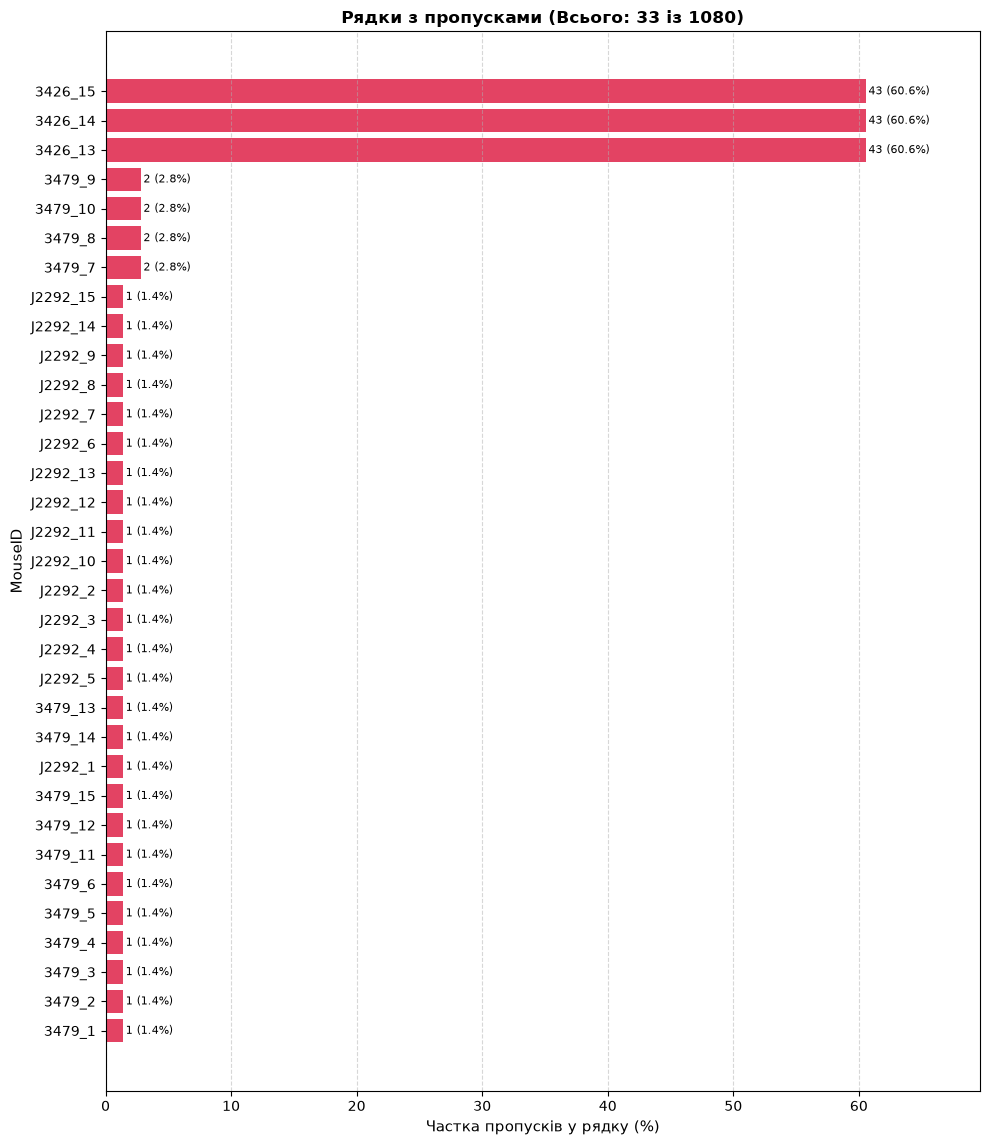

In [50]:
# Plot for NAs in rows - AI generated

# 1. Розрахунок пропусків по рядках для білків
row_na_counts = mice_dataset_clean[valid_protein_cols].isnull().sum(axis=1)
row_na_pct = mice_dataset_clean[valid_protein_cols].isnull().mean(axis=1) * 100

# 2. Фільтрація лише тих рядків, де є пропуски (>0)
na_rows = pd.DataFrame({
    'MouseID': mice_dataset['MouseID'],
    'na_count': row_na_counts,
    'na_pct': row_na_pct
})[row_na_counts > 0].sort_values(by='na_pct', ascending=True)

# 3. Побудова графіку
plt.figure(figsize=(10, max(5, len(na_rows) * 0.35)))
bars = plt.barh(na_rows['MouseID'], na_rows['na_pct'], color='crimson', alpha=0.8)

# 4. Аннотації з точної кількості (count) та відсотка (%) NAs
for bar, count, pct in zip(bars, na_rows['na_count'], na_rows['na_pct']):
    plt.text(pct + 0.2, bar.get_y() + bar.get_height()/2, 
             f'{int(count)} ({pct:.1f}%)', 
             va='center', fontsize=8, color='black')

plt.xlabel('Частка пропусків у рядку (%)', fontsize=11)
plt.ylabel('MouseID', fontsize=11)
plt.title(f'Рядки з пропусками (Всього: {len(na_rows)} із {len(mice_dataset_clean)})', fontsize=12, fontweight='bold')
plt.xlim(0, max(na_rows['na_pct'].max() * 1.15, 5))
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

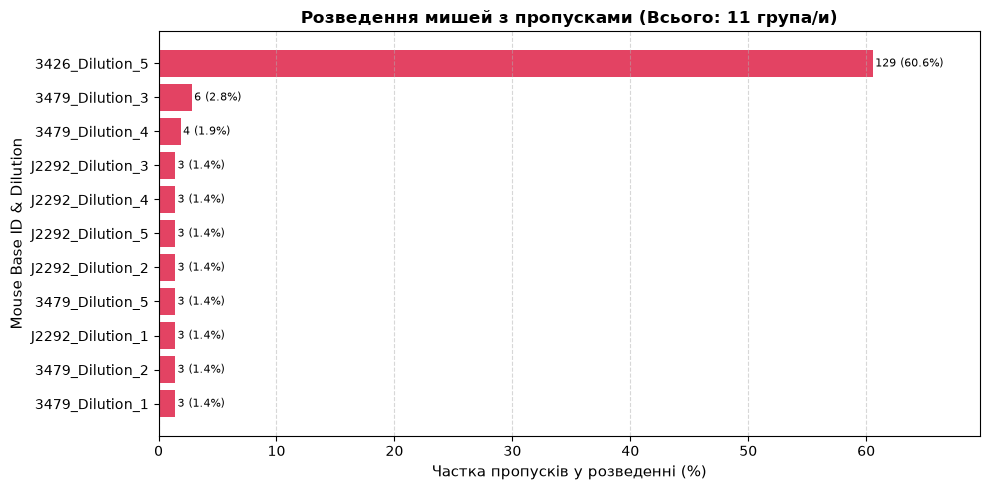

In [51]:
# 1. Агрегація NAs по мишах та розведеннях (Mouse_Base_ID + Dilution)
dilution_na = mice_dataset_clean.groupby(['Mouse_Base_ID', 'Dilution'])[valid_protein_cols].apply(
    lambda g: pd.Series({
        'na_count': g.isnull().sum().sum(),
        'na_pct': (g.isnull().sum().sum() / (g.shape[0] * g.shape[1])) * 100
    })
).reset_index()

# 2. Фільтрація лише тих розведень, де є пропуски (>0)
na_dilutions = dilution_na[dilution_na['na_count'] > 0].copy()
na_dilutions['Mouse_Dilution'] = (
    na_dilutions['Mouse_Base_ID'] + '_Dilution_' + na_dilutions['Dilution'].astype(str)
)
na_dilutions = na_dilutions.sort_values(by='na_pct', ascending=True)

# 3. Побудова графіку
plt.figure(figsize=(10, max(5, len(na_dilutions) * 0.35)))
bars = plt.barh(na_dilutions['Mouse_Dilution'], na_dilutions['na_pct'], color='crimson', alpha=0.8)

# 4. Аннотації з точної кількості (count) та відсотка (%) NAs
for bar, count, pct in zip(bars, na_dilutions['na_count'], na_dilutions['na_pct']):
    plt.text(pct + 0.2, bar.get_y() + bar.get_height()/2, 
             f'{int(count)} ({pct:.1f}%)', 
             va='center', fontsize=8, color='black')

plt.xlabel('Частка пропусків у розведенні (%)', fontsize=11)
plt.ylabel('Mouse Base ID & Dilution', fontsize=11)
plt.title(f'Розведення мишей з пропусками (Всього: {len(na_dilutions)} група/и)', fontsize=12, fontweight='bold')
plt.xlim(0, max(na_dilutions['na_pct'].max() * 1.15, 5))
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [54]:
dilution_na[dilution_na['na_pct']!=0]['Mouse_Base_ID'].unique()

<StringArray>
['3426', '3479', 'J2292']
Length: 3, dtype: str

In [ ]:
### 3425 5th dilution is problematic for many proteins - NAs are ~ evenly distributed across proteins

In [61]:
mouse_3479 = mice_dataset_clean[mice_dataset_clean['Mouse_Base_ID'] == '3479']

# NAs per protein and per dilution
na_by_dilution = mouse_3479.groupby('Dilution')[valid_protein_cols].apply(lambda g: g.isnull().sum())

# Removing proteins without NAs
na_crosstab = na_by_dilution.loc[:, (na_by_dilution > 0).any(axis=0)]
# Removing delutions without NAs
na_crosstab_filtered = na_crosstab.loc[(na_crosstab > 0).any(axis=1)]

print("Crosstab NAs (Dilution x Protein) for mouse 3479:")
print(na_crosstab)

Crosstab NAs (Dilution x Protein) for mouse 3479:
          ELK_N  MEK_N
Dilution              
1             3      0
2             3      0
3             3      3
4             3      1
5             3      0


In [ ]:
# ELK_N was not measured in 3479 at all
# MEK_N's dilution 3 is problematic

In [62]:
mouse_J2292 = mice_dataset_clean[mice_dataset_clean['Mouse_Base_ID'] == 'J2292']

# NAs per protein and per dilution
na_by_dilution = mouse_J2292.groupby('Dilution')[valid_protein_cols].apply(lambda g: g.isnull().sum())

# Removing proteins without NAs
na_crosstab = na_by_dilution.loc[:, (na_by_dilution > 0).any(axis=0)]
# Removing delutions without NAs
na_crosstab_filtered = na_crosstab.loc[(na_crosstab > 0).any(axis=1)]

print("Crosstab NAs (Dilution x Protein) for mouse J2292:")
print(na_crosstab)

Crosstab NAs (Dilution x Protein) for mouse J2292:
          Bcatenin_N
Dilution            
1                  3
2                  3
3                  3
4                  3
5                  3


In [63]:
# Bcatenin_N was not measures at all

In [ ]:
# In this case choosing between proteins or samples removing, reduction of fetures is less harmful because p > n
# So with 3 samples where NAs are sill present, the strategy is the following:
# - among 5 dilutions, we definitrly should not pick 5th, because it will lead to losing 3425.
#   Chosing 1-4 dilutions will save 3425 in the dataset
# - 3479 will be preserved if we delete ELK_N and avoid dilution 3
# - J2292 will be preserved if Bcatenin_N is deleted

# Remove ELK_N, Bcatenin_N and avoid dilutions 3 and 5 - saves all mice

In [65]:
mice_dataset_sub = mice_dataset_clean[mice_dataset_clean['Dilution'] == 2].drop(
    columns=['ELK_N', 'Bcatenin_N'], errors='ignore'
)

print(f"New dataset: {mice_dataset_sub.shape}")

New dataset: (216, 77)


In [71]:
mice_dataset_sub.columns

Index(['MouseID', 'Mouse_Base_ID', 'Dilution', 'Tech_Rep', 'Genotype',
       'Treatment', 'Behavior', 'class', 'ADARB1_N', 'AKT_N', 'AMPKA_N',
       'APP_N', 'ARC_N', 'AcetylH3K9_N', 'BAX_N', 'BDNF_N', 'BRAF_N',
       'CAMKII_N', 'CDK5_N', 'CREB_N', 'CaNA_N', 'DSCR1_N', 'DYRK1A_N',
       'ERBB4_N', 'ERK_N', 'GFAP_N', 'GSK3B_N', 'GluR3_N', 'GluR4_N', 'IL1B_N',
       'ITSN1_N', 'JNK_N', 'MEK_N', 'MTOR_N', 'NR1_N', 'NR2A_N', 'NR2B_N',
       'NUMB_N', 'P3525_N', 'P38_N', 'P70S6_N', 'PKCA_N', 'PSD95_N',
       'RAPTOR_N', 'RRP1_N', 'RSK_N', 'S6_N', 'SHH_N', 'SNCA_N', 'SOD1_N',
       'SYP_N', 'TIAM1_N', 'TRKA_N', 'Tau_N', 'Ubiquitin_N', 'nNOS_N',
       'pAKT_N', 'pBRAF_N', 'pCAMKII_N', 'pCASP9_N', 'pCREB_N', 'pELK_N',
       'pERK_N', 'pGSK3B_N', 'pGSK3B_Tyr216_N', 'pJNK_N', 'pMEK_N', 'pMTOR_N',
       'pNR1_N', 'pNR2A_N', 'pNR2B_N', 'pNUMB_N', 'pP70S6_N', 'pPKCAB_N',
       'pPKCG_N', 'pRSK_N', 'pS6_N'],
      dtype='str')

In [72]:
print("All samples/mice are preserved")
print("Dilution 2 is chosen for the further analysis")
print(f"{len(mice_dataset_sub.columns)-8} proteins out of {len(protein_cols)} retained")

All samples/mice are preserved
Dilution 2 is chosen for the further analysis
69 proteins out of 77 retained


In [74]:
print("Total missing cell values:", mice_dataset_sub[mice_dataset_sub.columns[8:]].isnull().sum().sum())
print("Non-finite values:", (~np.isfinite(mice_dataset_sub[mice_dataset_sub.columns[8:]].select_dtypes(include=np.number))).sum().sum())
print("Negative values:", (mice_dataset_sub[mice_dataset_sub.columns[8:]] < 0).sum().sum())

Total missing cell values: 0
Non-finite values: 0
Negative values: 0


In [78]:
### Duplicates check

print("Duplicates (protein levels):", mice_dataset_sub[mice_dataset_sub.columns[8:]].duplicated().sum())
constant_cols = [col for col in mice_dataset_sub.columns[8:] if mice_dataset_sub[col].nunique() <= 1]
print("Constant columns:", constant_cols)

Duplicates (protein levels): 0
Constant columns: []


In [101]:
top_var_proteins = mice_dataset_sub[mice_dataset_sub.columns[8:]].var().sort_values(ascending=False).head(10)
print("Топ-10 білків за варіативністю (Dilution 2):\n", top_var_proteins)

Топ-10 білків за варіативністю (Dilution 2):
 pCAMKII_N    1.602515
NR2A_N       0.624516
pPKCG_N      0.304794
pELK_N       0.272942
ERK_N        0.270596
pPKCAB_N     0.218876
ADARB1_N     0.124098
pERK_N       0.117633
CaNA_N       0.110049
SOD1_N       0.087561
dtype: float64


In [75]:
### We do not need to have 3 replicates for each mouse, so proteins will be means of their 3 measurements within dilution 2

meta_cols = list(mice_dataset_sub.columns[:8])
protein_cols = list(mice_dataset_sub.columns[8:])

# Aggregation
agg_dict = {col: 'first' for col in meta_cols}
agg_dict.update({col: 'mean' for col in protein_cols})

df_aggregated = (
    mice_dataset_sub
    .groupby(['Mouse_Base_ID', 'Dilution'], as_index=False)
    .agg(agg_dict)
)

print(f"Initial dataset shape: {mice_dataset_sub.shape}")
print(f"Dataset without replicates: {df_aggregated.shape}")

Initial dataset shape: (216, 77)
Dataset without replicates: (72, 77)


In [81]:
import seaborn as sns

In [97]:
### Scdaling + PCA

X_scaled = StandardScaler().fit_transform(df_aggregated[protein_cols])

def plot_pca(data_scaled, labels, title):
    pca = PCA(n_components=2)
    coords = pca.fit_transform(data_scaled)
    plt.figure(figsize=(7, 5))
    sns.scatterplot(x=coords[:, 0], y=coords[:, 1], hue=labels, style=labels, alpha=0.85)
    plt.title(f"{title}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

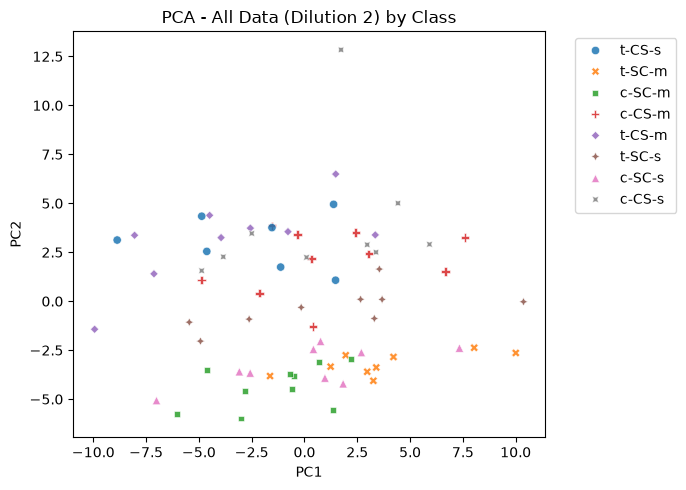

In [98]:
plot_pca(X_scaled, df_aggregated['class'], "PCA - All Data (Dilution 2) by Class")

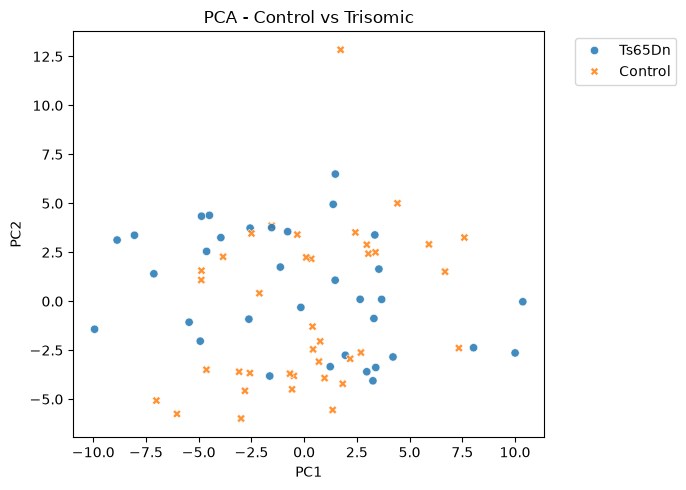

In [99]:
plot_pca(X_scaled, df_aggregated['Genotype'], "PCA - Control vs Trisomic")

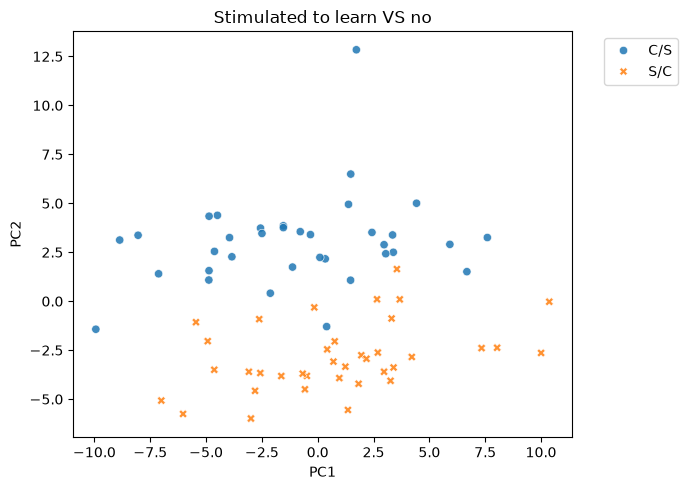

In [100]:
plot_pca(X_scaled, df_aggregated['Behavior'], "Stimulated to learn VS no")

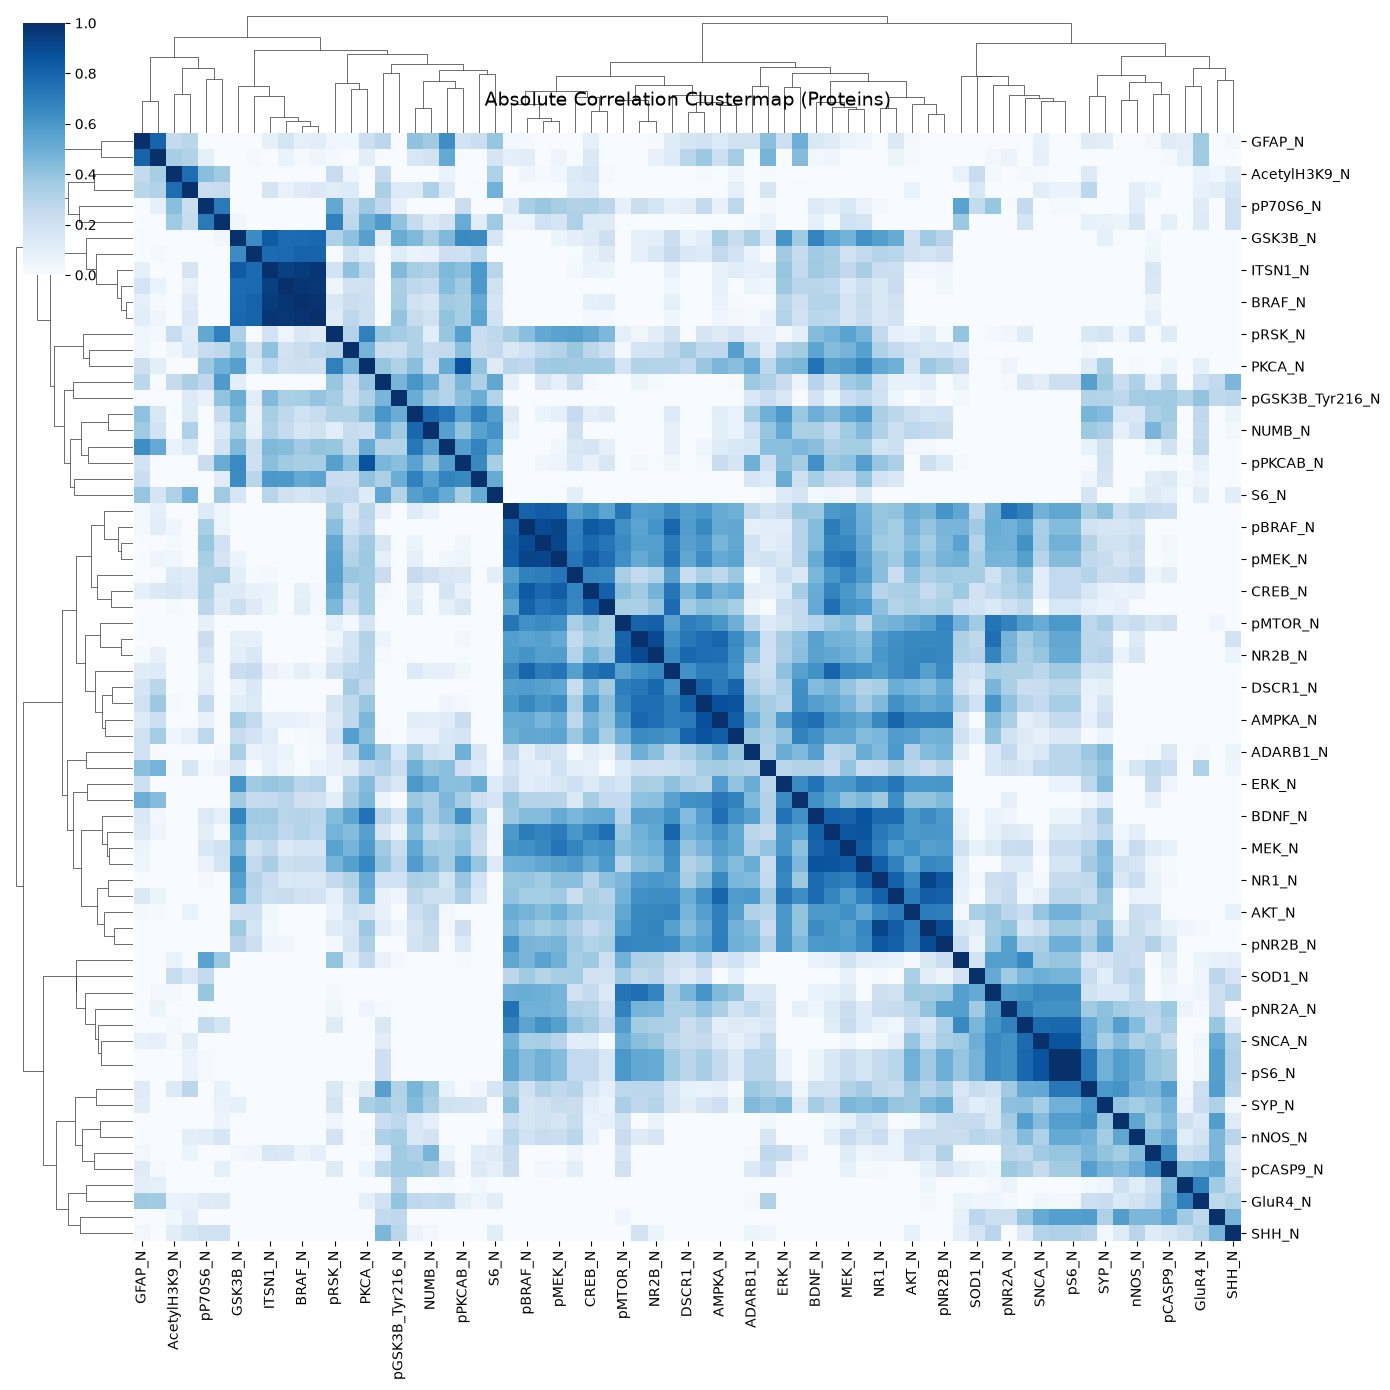

In [103]:
### Correlated proteins
corr_matrix = df_aggregated[protein_cols].corr()#.abs()

# Clustermap
g = sns.clustermap(
    corr_matrix, 
    cmap='Blues', 
    vmin=0, vmax=1,
    figsize=(14, 14),
    dendrogram_ratio=(0.1, 0.1),
    cbar_pos=(0.02, 0.8, 0.03, 0.18)
)

g.ax_heatmap.set_title("Absolute Correlation Clustermap (Proteins)", fontsize=14, pad=20)
plt.show()

In [104]:
### ML problem - understand which control, stimulated to learn mice were trated with memantine or saline
# The classes would be c-CS-m and c-CS-s

final_data = df_aggregated[df_aggregated['class'].isin(['c-CS-m', 'c-CS-s'])]
final_data.shape

(19, 77)

In [106]:
final_data["class"].value_counts()

class
c-CS-m    10
c-CS-s     9
Name: count, dtype: int64

In [ ]:
### According to TIDY data principles, we should have decomposed class variable to 3 cols - genotype, stimulation, drug.
# But with the current ML task and subsetting this action is unnecessary. 
# All mice are already of healthy genotype, all are stimulated to learn, and the only difference between them
# is the drug they were injected with, which is clearly represented in 'class'.

In [108]:
final_data.columns

Index(['MouseID', 'Mouse_Base_ID', 'Dilution', 'Tech_Rep', 'Genotype',
       'Treatment', 'Behavior', 'class', 'ADARB1_N', 'AKT_N', 'AMPKA_N',
       'APP_N', 'ARC_N', 'AcetylH3K9_N', 'BAX_N', 'BDNF_N', 'BRAF_N',
       'CAMKII_N', 'CDK5_N', 'CREB_N', 'CaNA_N', 'DSCR1_N', 'DYRK1A_N',
       'ERBB4_N', 'ERK_N', 'GFAP_N', 'GSK3B_N', 'GluR3_N', 'GluR4_N', 'IL1B_N',
       'ITSN1_N', 'JNK_N', 'MEK_N', 'MTOR_N', 'NR1_N', 'NR2A_N', 'NR2B_N',
       'NUMB_N', 'P3525_N', 'P38_N', 'P70S6_N', 'PKCA_N', 'PSD95_N',
       'RAPTOR_N', 'RRP1_N', 'RSK_N', 'S6_N', 'SHH_N', 'SNCA_N', 'SOD1_N',
       'SYP_N', 'TIAM1_N', 'TRKA_N', 'Tau_N', 'Ubiquitin_N', 'nNOS_N',
       'pAKT_N', 'pBRAF_N', 'pCAMKII_N', 'pCASP9_N', 'pCREB_N', 'pELK_N',
       'pERK_N', 'pGSK3B_N', 'pGSK3B_Tyr216_N', 'pJNK_N', 'pMEK_N', 'pMTOR_N',
       'pNR1_N', 'pNR2A_N', 'pNR2B_N', 'pNUMB_N', 'pP70S6_N', 'pPKCAB_N',
       'pPKCG_N', 'pRSK_N', 'pS6_N'],
      dtype='str')

In [112]:
X = final_data[final_data.columns[8:]]
y = final_data['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # even class distribution
)

print("--- TRAIN ---")
print("X_train:", X_train.shape)
print("Distriibution y_train (%):\n", y_train.value_counts(normalize=True).round(3))

print("\n--- VALIDATION ---")
print("X_val:", X_test.shape)
print("Distriibution y_val (%):\n", y_test.value_counts(normalize=True).round(3))

--- TRAIN ---
X_train: (15, 69)
Distriibution y_train (%):
 class
c-CS-m    0.533
c-CS-s    0.467
Name: proportion, dtype: float64

--- VALIDATION ---
X_val: (4, 69)
Distriibution y_val (%):
 class
c-CS-m    0.5
c-CS-s    0.5
Name: proportion, dtype: float64
